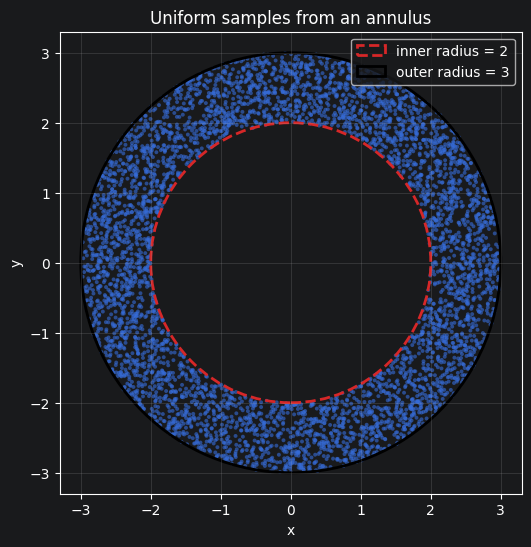

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Uniform sampling from the 2D annulus: 2 <= radius <= 3
rng = np.random.default_rng(42)
n_points = 5_000
inner_radius = 2.0
outer_radius = 3.0

theta = rng.uniform(0.0, 2.0 * np.pi, n_points)
r = np.sqrt(rng.uniform(inner_radius**2, outer_radius**2, n_points))

x = r * np.cos(theta)
y = r * np.sin(theta)
points = np.column_stack((x, y))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.6, edgecolors='none')

inner_boundary = plt.Circle((0, 0), inner_radius, fill=False, linestyle='--', color='tab:red', linewidth=2, label='inner radius = 2')
outer_boundary = plt.Circle((0, 0), outer_radius, fill=False, color='black', linewidth=2, label='outer radius = 3')
ax.add_patch(inner_boundary)
ax.add_patch(outer_boundary)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Uniform samples from an annulus')
ax.legend(loc='upper right')
ax.grid(alpha=0.25)
plt.show()

Left Gaussian retained 2500 points; acceptance rate in generated batches: 68.35%
Right Gaussian retained 2500 points; acceptance rate in generated batches: 68.10%


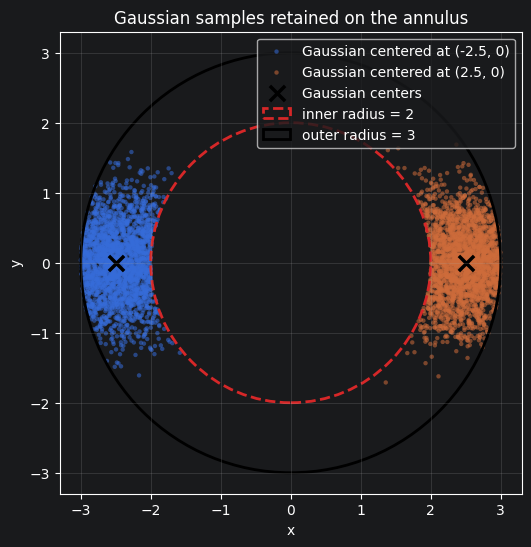

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussian datasets conditioned to lie on the annulus: 2 <= radius <= 3
rng = np.random.default_rng(123)
inner_radius = 2.0
outer_radius = 3.0
variance = 0.25
n_points_per_gaussian = 2_500

mean_left = np.array([-2.5, 0.0])
mean_right = np.array([2.5, 0.0])

def in_annulus(samples, inner_radius=2.0, outer_radius=3.0):
    radii = np.linalg.norm(samples, axis=1)
    return (radii >= inner_radius) & (radii <= outer_radius)

def sample_gaussian_on_annulus(mean, variance, n_samples, rng, inner_radius=2.0, outer_radius=3.0, batch_size=10_000):
    std = np.sqrt(variance)
    accepted = []
    n_drawn = 0
    n_accepted = 0

    while n_accepted < n_samples:
        candidates = rng.normal(loc=mean, scale=std, size=(batch_size, 2))
        n_drawn += len(candidates)
        kept = candidates[in_annulus(candidates, inner_radius, outer_radius)]

        if len(kept) > 0:
            accepted.append(kept)
            n_accepted += len(kept)

    return np.vstack(accepted)[:n_samples], n_drawn, n_accepted

left_gaussian_points, left_drawn, left_accepted = sample_gaussian_on_annulus(
    mean_left, variance, n_points_per_gaussian, rng, inner_radius, outer_radius
)
right_gaussian_points, right_drawn, right_accepted = sample_gaussian_on_annulus(
    mean_right, variance, n_points_per_gaussian, rng, inner_radius, outer_radius
)

gaussian_ring_points = np.vstack((left_gaussian_points, right_gaussian_points))
gaussian_ring_labels = np.concatenate((
    np.zeros(n_points_per_gaussian, dtype=int),
    np.ones(n_points_per_gaussian, dtype=int),
))

print(f'Left Gaussian retained {n_points_per_gaussian} points; acceptance rate in generated batches: {left_accepted / left_drawn:.2%}')
print(f'Right Gaussian retained {n_points_per_gaussian} points; acceptance rate in generated batches: {right_accepted / right_drawn:.2%}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(left_gaussian_points[:, 0], left_gaussian_points[:, 1], s=10, alpha=0.55, edgecolors='none', label='Gaussian centered at (-2.5, 0)')
ax.scatter(right_gaussian_points[:, 0], right_gaussian_points[:, 1], s=10, alpha=0.55, edgecolors='none', label='Gaussian centered at (2.5, 0)')
ax.scatter([mean_left[0], mean_right[0]], [mean_left[1], mean_right[1]], marker='x', s=120, linewidths=2.5, color='black', label='Gaussian centers')

inner_boundary = plt.Circle((0, 0), inner_radius, fill=False, linestyle='--', color='tab:red', linewidth=2, label='inner radius = 2')
outer_boundary = plt.Circle((0, 0), outer_radius, fill=False, color='black', linewidth=2, label='outer radius = 3')
ax.add_patch(inner_boundary)
ax.add_patch(outer_boundary)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gaussian samples retained on the annulus')
ax.legend(loc='upper right')
ax.grid(alpha=0.25)
plt.show()